# Análisis Exploratorio de Datos



## 1. Definición del Problema

En este trabajo se analizarán las solicitudes de medicamentos de alto costo, dispositivos y actos médicos presentadas al Fondo Nacional de Recursos (FNR) durante los años 2024 y 2025.

El objetivo es realizar un análisis exploratorio de los datos (EDA) para identificar las principales características de las solicitudes y explorar qué variables podrían estar asociadas al estado de autorización de las mismas.

La variable objetivo del análisis será el estado de la solicitud, distinguiendo entre solicitudes autorizadas y no autorizadas.

No se dispone de metadatos ni documentación adicional del conjunto de datos, por lo que algunas definiciones e interpretaciones se realizarán a partir de los nombres de las variables.

## Paso 2: Recopilación de datos

> Dataset de [FNR Solicitudes](https://www.fnr.gub.uy/estadisticas-2024/)

In [1]:
from email.quoprimime import header_encode
!python -m pip install -r ../requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest


In [3]:
!python -m pip list

Package                   Version
------------------------- ------------
altair                    6.2.2
anyio                     4.14.2
asttokens                 3.0.2
attrs                     26.1.0
blinker                   1.9.0
certifi                   2026.7.22
charset-normalizer        3.5.1
click                     8.4.2
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.21
executing                 2.2.1
fonttools                 4.63.0
h11                       0.16.0
httptools                 0.8.0
idna                      3.19
ipykernel                 7.3.0
ipython                   9.16.1
ipython_pygments_lexers   1.1.1
itsdangerous              2.2.0
jedi                      0.20.0
Jinja2                    3.1.6
joblib                    1.5.3
jsonschema                4.26.0
jsonschema-specifications 2025.9.1
jupyter_client            8.9.1
jupyter_core    

### Importamos los datos y creamos el DataFrame

In [153]:
df = pd.read_csv("../data/raw/FNR_solicitudes_2024_2025.csv", encoding="latin1")
df

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solcitud,fecha_autorización,pac_enmascarado,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen
0,Acto Médico,ACTOS CARDIOLOGÍA,201,Cateterismo diagnóstico infantil,7/28/2025,AUTORIZADO,8/8/2025,8236731,1,M,CANELONES,Hospital Policial,ASSE,CANELONES,PUBLICO
1,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,5/7/2025,AUTORIZADO,5/8/2025,8119160,62,M,MONTEVIDEO,Hospital Español,ASSE,MONTEVIDEO,PUBLICO
2,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,7/2/2025,AUTORIZADO,7/7/2025,8098843,71,F,MONTEVIDEO,Hospital Pasteur,ASSE,MONTEVIDEO,PUBLICO
3,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/20/2025,AUTORIZADO,3/14/2025,8244840,56,M,ROCHA,Centro departamental de Rocha,ASSE,ROCHA,PUBLICO
4,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/27/2025,AUTORIZADO,3/5/2025,8708606,79,F,RIO NEGRO,Centro departamental de Rio Negro,ASSE,RIO NEGRO,PUBLICO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71870,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,03/06/2024,AUTORIZADO,20/06/2024,8216632,66,M,TACUAREMBO,COMTA IAMPP,IAMC,TACUAREMBO,PRIVADO
71871,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,21/06/2024,AUTORIZADO,04/07/2024,8110928,68,F,CANELONES,CASMU,IAMC,MONTEVIDEO,PRIVADO
71872,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,02/12/2024,AUTORIZADO,30/01/2025,8224793,42,M,LAVALLEJA,CAMDEL IAMPP,IAMC,LAVALLEJA,PRIVADO
71873,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,29/10/2024,AUTORIZADO,05/12/2024,8219763,63,M,MONTEVIDEO,Hospital Maciel,ASSE,MONTEVIDEO,PUBLICO


In [154]:
df.head()

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solcitud,fecha_autorización,pac_enmascarado,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen
0,Acto Médico,ACTOS CARDIOLOGÍA,201,Cateterismo diagnóstico infantil,7/28/2025,AUTORIZADO,8/8/2025,8236731,1,M,CANELONES,Hospital Policial,ASSE,CANELONES,PUBLICO
1,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,5/7/2025,AUTORIZADO,5/8/2025,8119160,62,M,MONTEVIDEO,Hospital Español,ASSE,MONTEVIDEO,PUBLICO
2,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,7/2/2025,AUTORIZADO,7/7/2025,8098843,71,F,MONTEVIDEO,Hospital Pasteur,ASSE,MONTEVIDEO,PUBLICO
3,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/20/2025,AUTORIZADO,3/14/2025,8244840,56,M,ROCHA,Centro departamental de Rocha,ASSE,ROCHA,PUBLICO
4,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/27/2025,AUTORIZADO,3/5/2025,8708606,79,F,RIO NEGRO,Centro departamental de Rio Negro,ASSE,RIO NEGRO,PUBLICO


## Paso 3:Análisis Descriptivo

In [155]:
df.shape

(71875, 15)

Obtenemos información sobre tipo de datos y valores nulos

In [156]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71875 entries, 0 to 71874
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   tipo_prestacion          71875 non-null  str  
 1   area_prestacion          71875 non-null  str  
 2   prestacion_cod           71875 non-null  int64
 3   prestacion_desc          71875 non-null  str  
 4   fecha_solicitud          71875 non-null  str  
 5   estado_solcitud          71875 non-null  str  
 6   fecha_autorización       68691 non-null  str  
 7   pac_enmascarado          71875 non-null  int64
 8   edad_años                71875 non-null  int64
 9   sexo                     71875 non-null  str  
 10  departamento_residencia  71875 non-null  str  
 11  prestador_salud          71875 non-null  str  
 12  prestador_tipo           71875 non-null  str  
 13  departamento_prestador   71875 non-null  str  
 14  prestador_origen         71875 non-null  str  
dtypes: int64(3), 

In [157]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
prestacion_cod,71875.0,1.558465e+03,1735.801892,101.0,302.0,1101.0,2102.0,6007.0
pac_enmascarado,71875.0,8.199454e+06,117602.222407,7778195.0,8178992.5,8230323.0,8247225.5,8747240.0
edad_años,71875.0,6.349226e+01,17.540975,-32.0,56.0,67.0,75.0,104.0


Se observa:
1. Dos columnas de fecha que están como tipo de dato texto: fecha_solicitud y fecha_autorización
2. La columna fecha_autorización presenta valores faltantes. De un total de 71.875 registros, solo 68.691 contienen información en esta variable, por lo que existen 3.184 registros sin fecha de autorización (4,43 % del total). Una posible explicación es que correspondan a solicitudes que aún no han finalizado su proceso de autorización; sin embargo, esta hipótesis debería validarse con el conocimiento del negocio o las reglas operativas del proceso.
3. La columna estado_solicitud tiene el nombre mal escrito
4. La columna edad tiene al menos un valor incorrecto, ya que el mínimo está en negativo

## Paso 4: Limpieza de Datos

### Analizamos los campos de fechas

In [158]:
df[["fecha_solicitud", "fecha_autorización"]].dtypes

fecha_solicitud       str
fecha_autorización    str
dtype: object

Analizamos la columna fecha_autorización

In [159]:
partes = df["fecha_autorización"].str.split("/", expand=True)
num1 = pd.to_numeric(partes[0], errors="coerce")
num2 = pd.to_numeric(partes[1], errors="coerce")
mask_ddmm = num1 > 12
mask_mmdd = num2 > 12
mask_ambiguas = (num1 <= 12) & (num2 <= 12)
print("DD/MM/YYYY:", mask_ddmm.sum())
print("MM/DD/YYYY:", mask_mmdd.sum())
print("Ambiguas:", mask_ambiguas.sum())

DD/MM/YYYY: 21544
MM/DD/YYYY: 21797
Ambiguas: 25350


In [160]:
total = len(df)
print(f"DD/MM/YYYY: {mask_ddmm.sum()} ({mask_ddmm.sum()/total:.1%})")
print(f"MM/DD/YYYY: {mask_mmdd.sum()} ({mask_mmdd.sum()/total:.1%})")
print(f"Ambiguas: {mask_ambiguas.sum()} ({mask_ambiguas.sum()/total:.1%})")

DD/MM/YYYY: 21544 (30.0%)
MM/DD/YYYY: 21797 (30.3%)
Ambiguas: 25350 (35.3%)


Observamos que el 35.3% de los valores de la columna fecha_autorización tienen valores ambiguos, ya que no podemos determinar cuál es el mes y cuál es el día.
Crearemos una nueva columna con el dato del año de autorización para quedarnos solo con el dato seguro que pueda aportar al análisis.

In [161]:
df["anio_autorización"] = df["fecha_autorización"].str[-4:]

Verificamos la creación de la nueva columna anio_autorización

In [162]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71875 entries, 0 to 71874
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   tipo_prestacion          71875 non-null  str  
 1   area_prestacion          71875 non-null  str  
 2   prestacion_cod           71875 non-null  int64
 3   prestacion_desc          71875 non-null  str  
 4   fecha_solicitud          71875 non-null  str  
 5   estado_solcitud          71875 non-null  str  
 6   fecha_autorización       68691 non-null  str  
 7   pac_enmascarado          71875 non-null  int64
 8   edad_años                71875 non-null  int64
 9   sexo                     71875 non-null  str  
 10  departamento_residencia  71875 non-null  str  
 11  prestador_salud          71875 non-null  str  
 12  prestador_tipo           71875 non-null  str  
 13  departamento_prestador   71875 non-null  str  
 14  prestador_origen         71875 non-null  str  
 15  anio_autoriza

Analizamos la columna fecha_solicitud

In [163]:
partes = df["fecha_solicitud"].str.split("/", expand=True)
num1 = pd.to_numeric(partes[0], errors="coerce")
num2 = pd.to_numeric(partes[1], errors="coerce")
mask_ddmm = num1 > 12
mask_mmdd = num2 > 12
mask_ambiguas = (num1 <= 12) & (num2 <= 12)
print("DD/MM/YYYY:", mask_ddmm.sum())
print("MM/DD/YYYY:", mask_mmdd.sum())
print("Ambiguas:", mask_ambiguas.sum())

DD/MM/YYYY: 21256
MM/DD/YYYY: 21927
Ambiguas: 28692


In [164]:
total = len(df)
print(f"DD/MM/YYYY: {mask_ddmm.sum()} ({mask_ddmm.sum()/total:.1%})")
print(f"MM/DD/YYYY: {mask_mmdd.sum()} ({mask_mmdd.sum()/total:.1%})")
print(f"Ambiguas: {mask_ambiguas.sum()} ({mask_ambiguas.sum()/total:.1%})")

DD/MM/YYYY: 21256 (29.6%)
MM/DD/YYYY: 21927 (30.5%)
Ambiguas: 28692 (39.9%)


Observamos que el 39.9% de los valores de la columna fecha_autorización tienen valores ambiguos, ya que no podemos determinar cuál es el mes y cuál es el día. Crearemos una nueva columna con el dato del año de solicitud para quedarnos solo con el dato seguro que pueda aportar al análisis.

In [165]:
df["anio_solicitud"] = df["fecha_solicitud"].str[-4:]

Verificamos la nueva columna anio_solicitud

In [166]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71875 entries, 0 to 71874
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   tipo_prestacion          71875 non-null  str  
 1   area_prestacion          71875 non-null  str  
 2   prestacion_cod           71875 non-null  int64
 3   prestacion_desc          71875 non-null  str  
 4   fecha_solicitud          71875 non-null  str  
 5   estado_solcitud          71875 non-null  str  
 6   fecha_autorización       68691 non-null  str  
 7   pac_enmascarado          71875 non-null  int64
 8   edad_años                71875 non-null  int64
 9   sexo                     71875 non-null  str  
 10  departamento_residencia  71875 non-null  str  
 11  prestador_salud          71875 non-null  str  
 12  prestador_tipo           71875 non-null  str  
 13  departamento_prestador   71875 non-null  str  
 14  prestador_origen         71875 non-null  str  
 15  anio_autoriza

Se visualiza que la columna estado_solcitud esta mal escrita y se corrige.

In [167]:
print(df.columns.tolist())

['tipo_prestacion', 'area_prestacion', 'prestacion_cod', 'prestacion_desc', 'fecha_solicitud', 'estado_solcitud', 'fecha_autorización', 'pac_enmascarado', 'edad_años', 'sexo', 'departamento_residencia', 'prestador_salud', 'prestador_tipo', 'departamento_prestador', 'prestador_origen', 'anio_autorización', 'anio_solicitud']


In [168]:
df.rename(columns={'estado_solcitud': 'estado_solicitud'}, inplace=True)
df

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solicitud,fecha_autorización,pac_enmascarado,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen,anio_autorización,anio_solicitud
0,Acto Médico,ACTOS CARDIOLOGÍA,201,Cateterismo diagnóstico infantil,7/28/2025,AUTORIZADO,8/8/2025,8236731,1,M,CANELONES,Hospital Policial,ASSE,CANELONES,PUBLICO,2025,2025
1,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,5/7/2025,AUTORIZADO,5/8/2025,8119160,62,M,MONTEVIDEO,Hospital Español,ASSE,MONTEVIDEO,PUBLICO,2025,2025
2,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,7/2/2025,AUTORIZADO,7/7/2025,8098843,71,F,MONTEVIDEO,Hospital Pasteur,ASSE,MONTEVIDEO,PUBLICO,2025,2025
3,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/20/2025,AUTORIZADO,3/14/2025,8244840,56,M,ROCHA,Centro departamental de Rocha,ASSE,ROCHA,PUBLICO,2025,2025
4,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/27/2025,AUTORIZADO,3/5/2025,8708606,79,F,RIO NEGRO,Centro departamental de Rio Negro,ASSE,RIO NEGRO,PUBLICO,2025,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71870,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,03/06/2024,AUTORIZADO,20/06/2024,8216632,66,M,TACUAREMBO,COMTA IAMPP,IAMC,TACUAREMBO,PRIVADO,2024,2024
71871,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,21/06/2024,AUTORIZADO,04/07/2024,8110928,68,F,CANELONES,CASMU,IAMC,MONTEVIDEO,PRIVADO,2024,2024
71872,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,02/12/2024,AUTORIZADO,30/01/2025,8224793,42,M,LAVALLEJA,CAMDEL IAMPP,IAMC,LAVALLEJA,PRIVADO,2025,2024
71873,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,29/10/2024,AUTORIZADO,05/12/2024,8219763,63,M,MONTEVIDEO,Hospital Maciel,ASSE,MONTEVIDEO,PUBLICO,2024,2024


### Análisis outliers

Analizamos los outliers que existen en el campo años.

In [169]:
df["edad_años"].describe()

count    71875.000000
mean        63.492257
std         17.540975
min        -32.000000
25%         56.000000
50%         67.000000
75%         75.000000
max        104.000000
Name: edad_años, dtype: float64

Filtramos las celdas mas bajas

In [170]:
df.sort_values("edad_años")[["edad_años", "sexo", "departamento_residencia"]].head(10)

,edad_años,sexo,departamento_residencia
65263,-32,M,LAVALLEJA
21269,0,F,RIVERA
10623,0,M,ROCHA
32236,0,M,MONTEVIDEO
32237,0,F,SORIANO
32238,0,M,TREINTA Y TRES
57217,0,F,RIO NEGRO
21234,0,M,MONTEVIDEO
57622,0,M,CANELONES
57160,0,F,TACUAREMBO


Revisamos que no hayan mas casos menores a 0

In [171]:
df[df["edad_años"] < 0]

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solicitud,fecha_autorización,pac_enmascarado,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen,anio_autorización,anio_solicitud
65263,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,08/08/2024,AUTORIZADO,17/02/2025,8244266,-32,M,LAVALLEJA,Seguro Americano,SEGURO PRIVADO,MONTEVIDEO,PRIVADO,2025,2024


El valor -32 es erroneo, vamos a sustituirlo por la media. Calculamos la media y lo sustituimos.

In [172]:
media_edad = df.loc[df["edad_años"] >= 0, "edad_años"].mean()

media_edad

np.float64(63.49358599771823)

In [173]:
media_edad = int(round(df.loc[df["edad_años"] >= 0, "edad_años"].mean()))

In [174]:
media_edad

63

In [175]:
df.loc[df["edad_años"] < 0, "edad_años"] = media_edad

In [176]:
df["edad_años"].min()

np.int64(0)

Analizo nuevamente los 10 mas bajos para confirmar que se modifico el valor negativo.

In [177]:
df.sort_values("edad_años")[["edad_años", "sexo", "departamento_residencia"]].head(10)

,edad_años,sexo,departamento_residencia
51828,0,M,MONTEVIDEO
54,0,M,CANELONES
37,0,M,MONTEVIDEO
38,0,F,MONTEVIDEO
21249,0,F,PAYSANDU
40,0,F,MONTEVIDEO
41,0,M,MONTEVIDEO
42,0,F,MONTEVIDEO
43,0,F,MONTEVIDEO
44,0,M,SAN JOSE


Filtramos las celdas mas altas

In [178]:
df.sort_values("edad_años", ascending=False)[["edad_años", "sexo", "departamento_residencia"]].head(10)

,edad_años,sexo,departamento_residencia
8131,104,F,MONTEVIDEO
55382,102,F,MONTEVIDEO
26250,102,F,MONTEVIDEO
8380,102,F,MONTEVIDEO
27947,102,F,MONTEVIDEO
5532,101,M,MONTEVIDEO
61977,101,F,MONTEVIDEO
8278,101,M,MONTEVIDEO
26391,100,F,MONTEVIDEO
42419,100,M,PAYSANDU


### Análisis de Duplicados

In [179]:
df.duplicated().sum()

np.int64(10)

Reviso los registros duplicados:

In [180]:
df[df.duplicated(keep=False)]

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solicitud,fecha_autorización,pac_enmascarado,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen,anio_autorización,anio_solicitud
11419,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,3/10/2025,NO AUTORIZADO,NaN,8227565,52,F,CANELONES,CASMU,IAMC,MONTEVIDEO,PRIVADO,NaN,2025
11420,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,3/10/2025,NO AUTORIZADO,NaN,8227565,52,F,CANELONES,CASMU,IAMC,MONTEVIDEO,PRIVADO,NaN,2025
11425,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,3/10/2025,NO AUTORIZADO,NaN,8259443,81,M,MONTEVIDEO,COSEM,IAMC,MONTEVIDEO,PRIVADO,NaN,2025
11426,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,3/10/2025,NO AUTORIZADO,NaN,8259443,81,M,MONTEVIDEO,COSEM,IAMC,MONTEVIDEO,PRIVADO,NaN,2025
32322,Acto Médico,ACTOS CARDIOLOGÍA,102,Cirugia cardiaca adultos,8/22/2025,NO AUTORIZADO,NaN,8260429,25,M,MONTEVIDEO,Hospital Maciel,ASSE,MONTEVIDEO,PUBLICO,NaN,2025
32323,Acto Médico,ACTOS CARDIOLOGÍA,102,Cirugia cardiaca adultos,8/22/2025,NO AUTORIZADO,NaN,8260429,25,M,MONTEVIDEO,Hospital Maciel,ASSE,MONTEVIDEO,PUBLICO,NaN,2025
48093,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,02/05/2024,AUTORIZADO,18/09/2024,8159471,59,F,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO,2024,2024
48094,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,02/05/2024,AUTORIZADO,18/09/2024,8159471,59,F,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO,2024,2024
48569,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,12/06/2024,NO AUTORIZADO,NaN,7904501,79,M,CANELONES,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO,NaN,2024
48570,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,12/06/2024,NO AUTORIZADO,NaN,7904501,79,M,CANELONES,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO,NaN,2024


Creo un nuevo DataFrame adicional para analizar duplicados sin la columna Pac_Enmascarado


In [181]:
df_sin_id = df.drop("pac_enmascarado", axis=1)

Analizo los duplicados en este nuevo Data Frame

In [182]:
df_sin_id.duplicated().sum()

np.int64(87)

Visualizo los nuevos duplicados

In [183]:
df_sin_id[df_sin_id.duplicated(keep=False)]

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solicitud,fecha_autorización,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen,anio_autorización,anio_solicitud
1409,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,2/24/2025,AUTORIZADO,3/5/2025,69,M,RIVERA,CASMER IAMPP,IAMC,RIVERA,PRIVADO,2025,2025
1410,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,2/24/2025,AUTORIZADO,3/5/2025,69,M,RIVERA,CASMER IAMPP,IAMC,RIVERA,PRIVADO,2025,2025
1449,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,2/27/2025,AUTORIZADO,3/6/2025,61,M,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO,2025,2025
1451,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,2/27/2025,AUTORIZADO,3/6/2025,61,M,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO,2025,2025
5285,Acto Médico,ACTOS CARDIOLOGÍA,421,TAVI,6/3/2025,AUTORIZADO,6/6/2025,84,M,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO,2025,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66199,Otra Prestación,OTRA ÁREA,2801,Cirugía fetal,27/08/2024,AUTORIZADO,01/10/2024,35,F,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO,2024,2024
66204,Otra Prestación,OTRA ÁREA,2801,Cirugía fetal,20/12/2024,AUTORIZADO,11/03/2025,43,F,MONTEVIDEO,COSEM,IAMC,MONTEVIDEO,PRIVADO,2025,2024
66205,Otra Prestación,OTRA ÁREA,2801,Cirugía fetal,20/12/2024,AUTORIZADO,11/03/2025,43,F,MONTEVIDEO,COSEM,IAMC,MONTEVIDEO,PRIVADO,2025,2024
71149,Otra Prestación,OTRA ÁREA,2801,Cirugía fetal,03/12/2024,AUTORIZADO,18/12/2024,25,F,CERRO LARGO,Centro auxiliar de Rio Branco,ASSE,CERRO LARGO,PUBLICO,2024,2024


Se eliminan a continuación los duplicados de todas las columnas, incluyendo la columna pac_enmascarado, ya que no se tiene forma de verificar sea un error, y es valido que sean solicitudes en la que coincidan todos los datos, pero sean distintos pacientes.

In [184]:
df = df.drop_duplicates()

Verifico nuevamente los duplicados para asegurarme fueron eliminados

In [185]:
df.duplicated().sum()

np.int64(0)

### Analisis de columna prestacion_cod

Antes de decidir eliminar esta columna que es un código del cual tenemos la descripción en el campo prestacion_desc, verificamos si existe una relación 1 a 1 con el campo de descripción. Verificamos si existen diferentes descripciones para un mismo código

In [150]:
df.groupby('prestacion_cod')['prestacion_desc'].nunique().max()

np.int64(1)

In [151]:
codigos_conflictivos = (
    df.groupby('prestacion_cod')['prestacion_desc']
      .nunique()
      .loc[lambda x: x > 1]
      .index
)

df[df['prestacion_cod'].isin(codigos_conflictivos)] \
    .sort_values('prestacion_cod') \
    [['prestacion_cod', 'prestacion_desc']] \
    .drop_duplicates()

,prestacion_cod,prestacion_desc


In [152]:
for desc in df.loc[df['prestacion_cod'] == 2701, 'prestacion_desc'].unique():
    print(desc)
    print('-' * 100)

Neuromodulacion en enf. de Parkinson y Distonias (Cirugia)
----------------------------------------------------------------------------------------------------


Visualizando los casos de prestacion cod que toman 2 valores en prestacion_desc se observa que son la misma prestación escrita de manera diferente, por lo cual se corrige.

In [127]:
df['prestacion_desc'] = df['prestacion_desc'].replace(
'Neuromodulación en enfermedad de Parkinson y distonías',
'Neuromodulacion en enf. de Parkinson y Distonias (Cirugia)')
df.groupby('prestacion_cod')['prestacion_desc'].nunique().max()

np.int64(1)

Se verifica haya quedado bien y ya no se muestren diferentes descripciones para el mismo codigo

In [128]:
codigos_conflictivos = (
    df.groupby('prestacion_cod')['prestacion_desc']
      .nunique()
      .loc[lambda x: x > 1]
      .index
)

df[df['prestacion_cod'].isin(codigos_conflictivos)] \
    .sort_values('prestacion_cod') \
    [['prestacion_cod', 'prestacion_desc']] \
    .drop_duplicates()

,prestacion_cod,prestacion_desc


### Eliminar información irrelevante
 ¿Son todas las características imprescindibles para realizar una predicción?
 Tras analizar la información disponible, se concluye que las siguientes columnas no aportan valor al objetivo del análisis o pueden ser reemplazadas por variables más confiables:
1. pac_enmascarado: corresponde a un identificador del paciente y no aporta información relevante para el objetivo predictivo del análisis.
2. prestacion_cod: contiene un código identificador que tiene una correspondencia única con la variable prestacion_desc.
3. fecha_solicitud: presenta un 39,9 % de registros con fechas ambiguas, por lo que fue reemplazada por la variable anio_solicitud, que conserva la información temporal confiable.
4. fecha_autorización: presenta un 35,3 % de registros con fechas ambiguas, por lo que fue reemplazada por la variable anio_autorizacion, que conserva únicamente el dato temporal seguro.

Antes de eliminar pac_enmascarado verificamos la cantidad de solicitudes por paciente.

In [186]:
solicitudes_por_paciente = (
df.groupby('pac_enmascarado')
.size()
.reset_index(name='cantidad_solicitudes'))
solicitudes_por_paciente["cantidad_solicitudes"].describe()

count    57661.000000
mean         1.246336
std          0.542713
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          7.000000
Name: cantidad_solicitudes, dtype: float64

La distribución de solicitudes por paciente muestra una alta concentración en una única solicitud. El 75% de los pacientes registró una sola solicitud durante el período analizado.

Se procede a eliminar las columnas pac_enmascarado, fecha_solitud, fecha_autorización y prestacion_cod:

In [187]:
df.drop(["pac_enmascarado", "fecha_solicitud", "fecha_autorización", "prestacion_cod"],axis=1,
inplace=True)
df

,tipo_prestacion,area_prestacion,prestacion_desc,estado_solicitud,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen,anio_autorización,anio_solicitud
0,Acto Médico,ACTOS CARDIOLOGÍA,Cateterismo diagnóstico infantil,AUTORIZADO,1,M,CANELONES,Hospital Policial,ASSE,CANELONES,PUBLICO,2025,2025
1,Acto Médico,ACTOS CARDIOLOGÍA,PCI-Cateterismo izq.adultos,AUTORIZADO,62,M,MONTEVIDEO,Hospital Español,ASSE,MONTEVIDEO,PUBLICO,2025,2025
2,Acto Médico,ACTOS CARDIOLOGÍA,PCI-Cateterismo izq.adultos,AUTORIZADO,71,F,MONTEVIDEO,Hospital Pasteur,ASSE,MONTEVIDEO,PUBLICO,2025,2025
3,Acto Médico,ACTOS CARDIOLOGÍA,PCI-ATCP c/cateterismo izq.,AUTORIZADO,56,M,ROCHA,Centro departamental de Rocha,ASSE,ROCHA,PUBLICO,2025,2025
4,Acto Médico,ACTOS CARDIOLOGÍA,PCI-ATCP c/cateterismo izq.,AUTORIZADO,79,F,RIO NEGRO,Centro departamental de Rio Negro,ASSE,RIO NEGRO,PUBLICO,2025,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71870,Acto Médico,ACTOS NEUROLOGÍA,Neuromodulacion en enf. de Parkinson y Distoni...,AUTORIZADO,66,M,TACUAREMBO,COMTA IAMPP,IAMC,TACUAREMBO,PRIVADO,2024,2024
71871,Acto Médico,ACTOS NEUROLOGÍA,Neuromodulacion en enf. de Parkinson y Distoni...,AUTORIZADO,68,F,CANELONES,CASMU,IAMC,MONTEVIDEO,PRIVADO,2024,2024
71872,Acto Médico,ACTOS NEUROLOGÍA,Neuromodulacion en enf. de Parkinson y Distoni...,AUTORIZADO,42,M,LAVALLEJA,CAMDEL IAMPP,IAMC,LAVALLEJA,PRIVADO,2025,2024
71873,Acto Médico,ACTOS NEUROLOGÍA,Neuromodulacion en enf. de Parkinson y Distoni...,AUTORIZADO,63,M,MONTEVIDEO,Hospital Maciel,ASSE,MONTEVIDEO,PUBLICO,2024,2024


Se exporta el archivo a la carpeta de procesados, ya que la limpieza de datos ya concluyó.

In [ ]:
df.to_csv('../data/processed/FNR_solicitudes_limpias_2024_2025.csv', index=False)

## Paso 5: Análisis Variables

### Análisis de Variables Univariantes Categóricas

Se analiza cuales son las variables categóricas.


Las variables con tipo de dato texto son:

In [34]:
    df.select_dtypes(include=["object", "string"]).columns

Index(['tipo_prestacion', 'area_prestacion', 'prestacion_desc',
       'estado_solcitud', 'sexo', 'departamento_residencia', 'prestador_salud',
       'prestador_tipo', 'departamento_prestador', 'prestador_origen',
       'anio_autorización', 'anio_solicitud'],
      dtype='str')

Revisamos cuantos valores distintos tienen las columnas

In [36]:
for col in df.select_dtypes(include=["object", "string"]).columns:
    print(col, "-", df[col].nunique())

tipo_prestacion - 4
area_prestacion - 21
prestacion_desc - 96
estado_solcitud - 2
sexo - 2
departamento_residencia - 19
prestador_salud - 120
prestador_tipo - 4
departamento_prestador - 20
prestador_origen - 2
anio_autorización - 5
anio_solicitud - 2


Revisamos que valores toman las columnas:

In [35]:
for col in df.select_dtypes(include=['object', 'string']):
    print(col)
    vc = df[col].value_counts().head(10)
    vc.index.name = None
    print(vc)

tipo_prestacion
Acto Médico                     51174
Tratamiento con medicamentos    11382
Otra Prestación                  8942
Dispositivos                      377
Name: count, dtype: int64
area_prestacion
ACTOS CARDIOLOGÍA            31837
ACTOS TRAUMATOLOGÍA          16027
OTRA ÁREA                     8942
TRATAMIENTOS ONCOLOGÍA        4169
TRATAMIENTOS HEMATOLOGÍA      1990
ACTOS NEFROLOGÍA              1502
TRATAMIENTOS INFECTOLOGÍA      966
ACTOS TRASPLANTES              959
TRATAMIENTOS REUMATOLOGÍA      949
TRATAMIENTOS NEUROLOGÍA        894
Name: count, dtype: int64
prestacion_desc
PCI-Cateterismo izq.adultos                  10820
PCI-ATCP c/cateterismo izq.                   8316
Protesis de rodilla - Implante                7023
Tomografía por emisión de positrones          6777
Protesis de cadera - Artrosis                 5286
Cirugia cardiaca adultos                      4205
Marcapasos - Implante                         2954
Protesis de cadera - Fractura            

#### Conclusión variables categóricas ####

Luego de haber identificado las variables que son texto y la cantidad de valores posibles que toman se concluye que son categóricas: tipo_prestacion, area_prestacion, prestacion_desc, estado_solcitud, sexo, departamento_residencia, prestador_salud, prestador_tipo, departamento_prestador, prestador_origen,anio_autorización, anio_solicitud.
Las columnas prestacion_desc y prestador_salud presentan una alta cardinalidad, es decir, contienen una gran cantidad de valores distintos. Por este motivo, no se realizará un análisis detallado de estas variables en esta etapa.
Además, ambas variables ya cuentan con una categorización de nivel superior que facilita su análisis: prestacion_desc se encuentra agrupada en la variable area_prestacion, mientras que prestador_salud se encuentra agrupada en prestador_tipo. Por lo tanto, el análisis exploratorio se centrará en estas categorías agregadas, dejando el estudio detallado de los valores individuales para una etapa posterior en caso de ser necesario

##### Histogramas variables categóricas #####

Representamos algunas de las variables categóricas con histogramas:

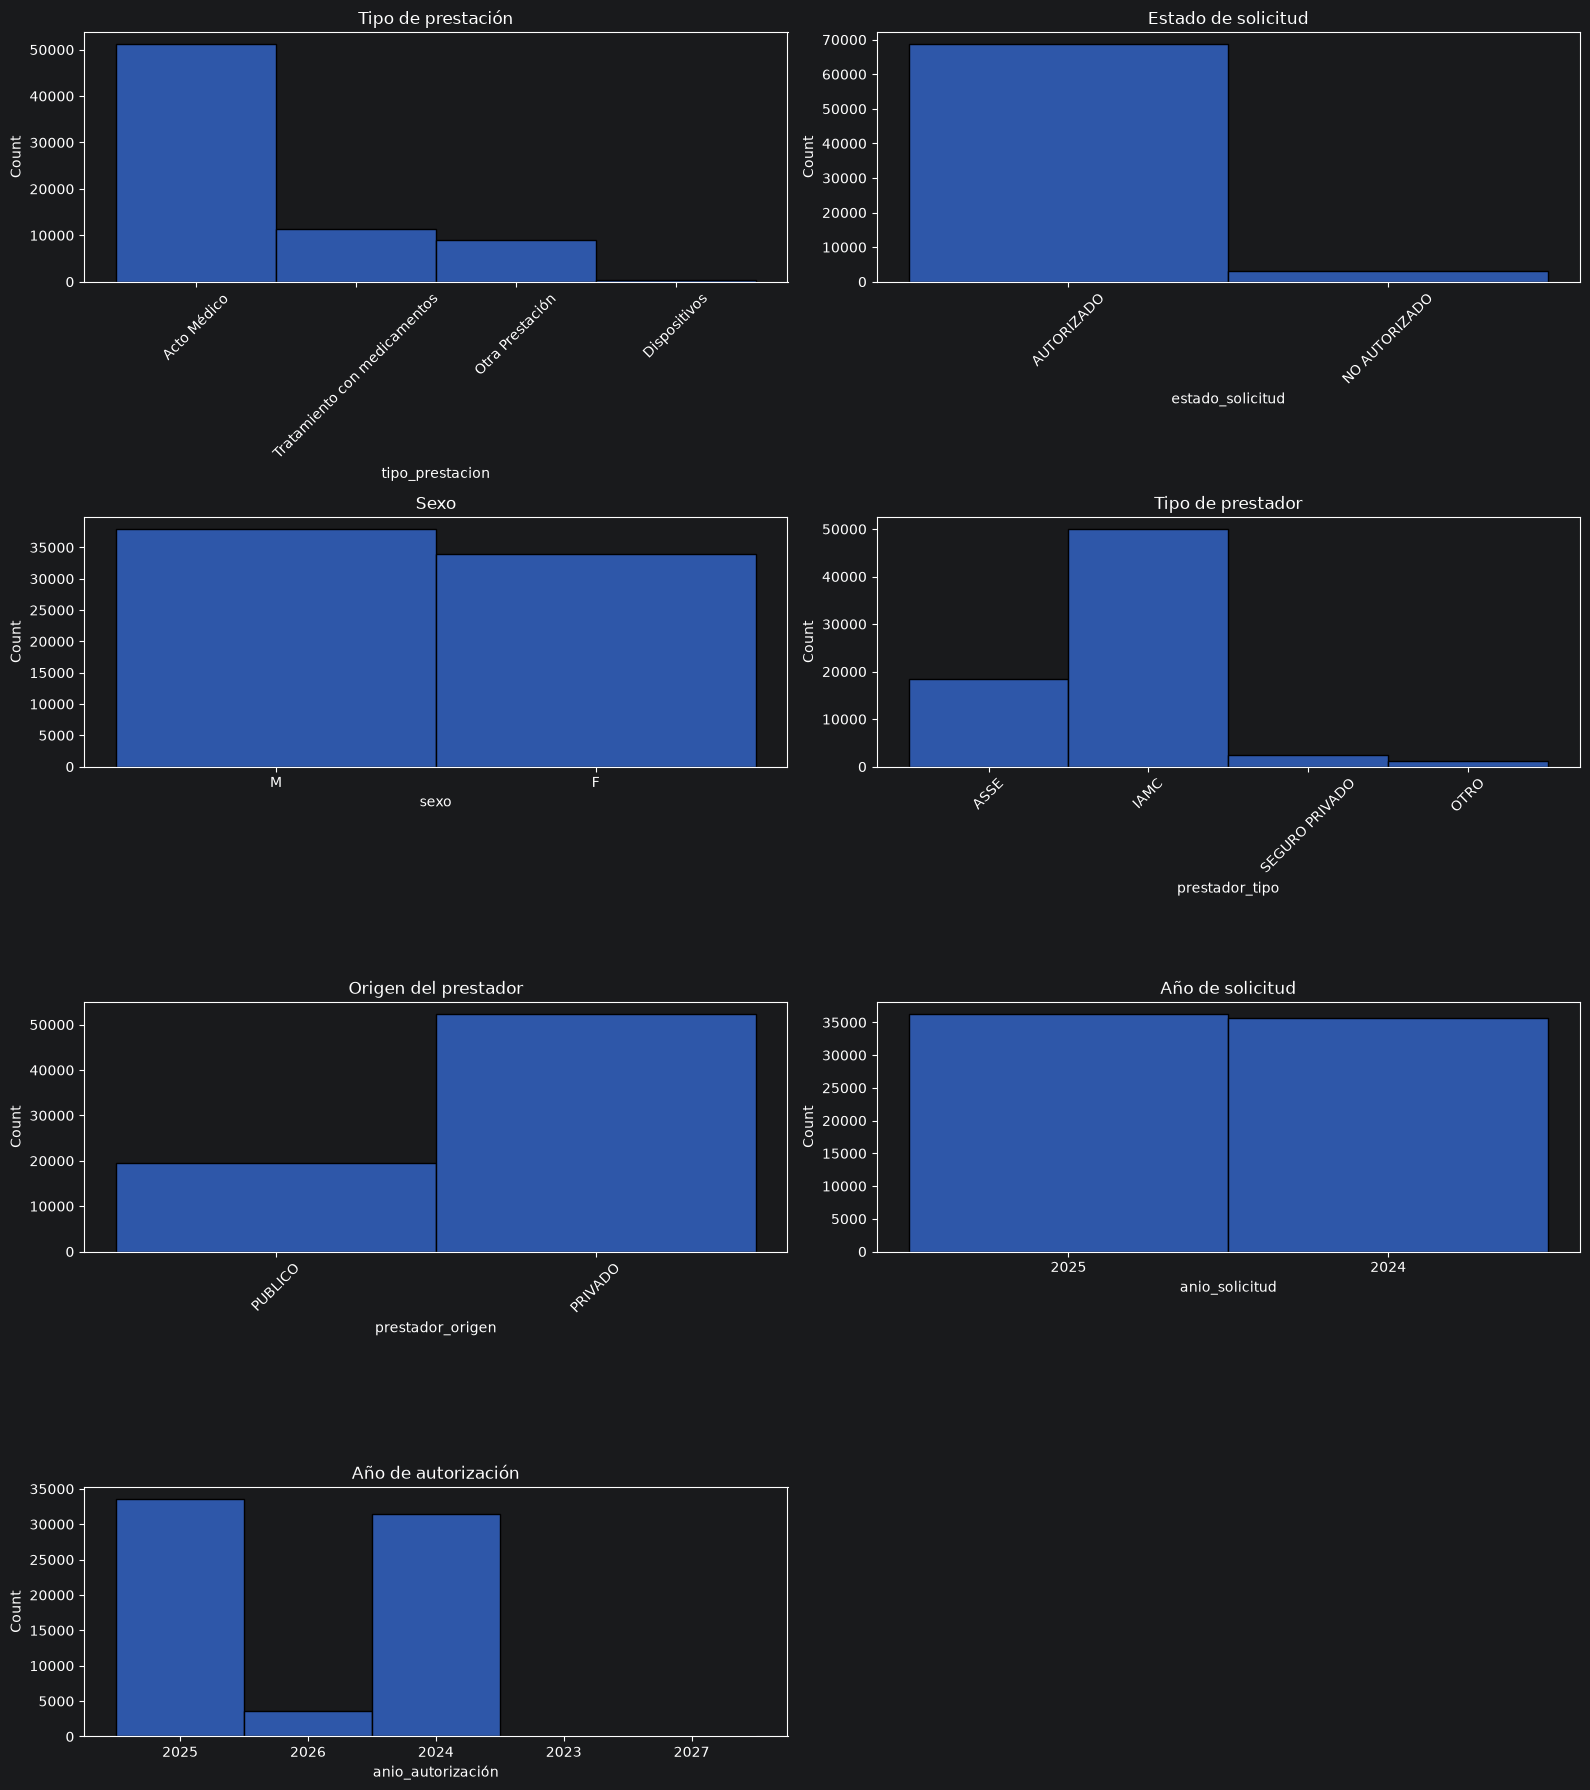

In [43]:
fig, axis = plt.subplots(4, 2, figsize=(16, 18))

sns.histplot(ax=axis[0, 0], data=df, x="tipo_prestacion")
axis[0, 0].set_title("Tipo de prestación")
axis[0, 0].tick_params(axis='x', rotation=45)

sns.histplot(ax=axis[0, 1], data=df, x="estado_solicitud")
axis[0, 1].set_title("Estado de solicitud")
axis[0, 1].tick_params(axis='x', rotation=45)

sns.histplot(ax=axis[1, 0], data=df, x="sexo")
axis[1, 0].set_title("Sexo")

sns.histplot(ax=axis[1, 1], data=df, x="prestador_tipo")
axis[1, 1].set_title("Tipo de prestador")
axis[1, 1].tick_params(axis='x', rotation=45)

sns.histplot(ax=axis[2, 0], data=df, x="prestador_origen")
axis[2, 0].set_title("Origen del prestador")
axis[2, 0].tick_params(axis='x', rotation=45)

sns.histplot(ax=axis[2, 1], data=df, x="anio_solicitud")
axis[2, 1].set_title("Año de solicitud")

sns.histplot(ax=axis[3, 0], data=df, x="anio_autorización")
axis[3, 0].set_title("Año de autorización")

axis[3, 1].set_visible(False)

plt.tight_layout()
plt.show()

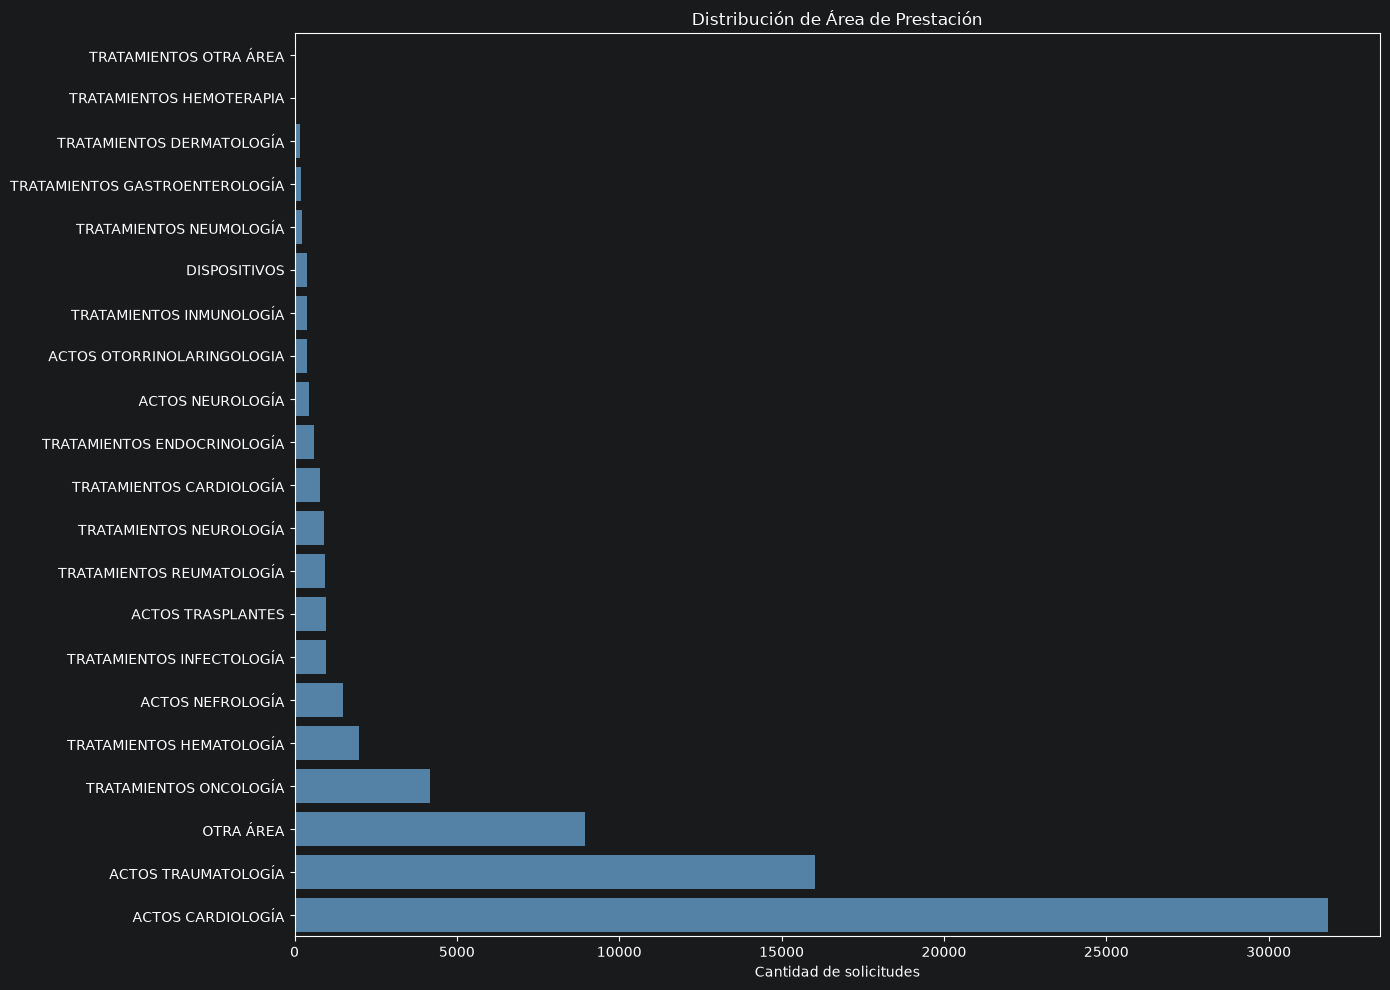

In [44]:
plt.figure(figsize=(14, 10))

areas = (
    df["area_prestacion"]
    .value_counts()
    .sort_values()
)

sns.barplot(
    x=areas.values,
    y=areas.index,
    color="steelblue"
)

plt.title("Distribución de Área de Prestación")
plt.xlabel("Cantidad de solicitudes")
plt.ylabel("")
plt.tight_layout()
plt.show()

### Observaciones

- Las solicitudes se concentran principalmente en **actos médicos**, que representan claramente el tipo de prestación más frecuente. Los tratamientos con medicamentos y otras prestaciones presentan una frecuencia considerablemente menor, mientras que los dispositivos representan una proporción muy reducida.

- La gran mayoría de las solicitudes del período analizado fueron **autorizadas**, mientras que las solicitudes no autorizadas representan una proporción mucho menor del total.

- La distribución de las solicitudes según **sexo** es relativamente equilibrada, aunque se observa una leve predominancia de pacientes de sexo masculino respecto a los de sexo femenino.

- En relación con el **tipo de prestador**, las IAMC (Instituciones de asistencia médica colectiva) concentran la mayor cantidad de solicitudes, seguidas por ASSE. Los prestadores privados y otros tipos de prestadores tienen una participación considerablemente menor.

- La distribución territorial muestra una marcada concentración de solicitudes correspondientes a pacientes residentes en **Montevideo**, seguido a distancia por los restantes departamentos.

- . **Los prestadores de tipo IAMC** concentran la mayor cantidad de solicitudes, seguidos por ASSE. La mayoría de las solicitudes se encuentran asociadas a prestadores de origen privado.

- El volumen de solicitudes es similar entre los años 2024 y 2025. Las autorizaciones se concentran principalmente en los años 2024 y 2025.

- En cuanto a las áreas de prestación, se observa una fuerte concentración en **Actos Cardiología y Actos Traumatología**, mientras que el resto de las áreas presentan una participación significativamente menor.

#### Análisis de Variables Univariantes Numéricas

Las variables numéricas son:

In [188]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
edad_años,71865.0,63.495067,17.536564,0.0,56.0,67.0,75.0,104.0


In [189]:
df["edad_años"].describe()

count    71865.000000
mean        63.495067
std         17.536564
min          0.000000
25%         56.000000
50%         67.000000
75%         75.000000
max        104.000000
Name: edad_años, dtype: float64

##### Histograma de variables numerica #####

Se construyó un histograma de la variable edad utilizando 20 intervalos (bins) para visualizar la distribución de los pacientes según su edad.

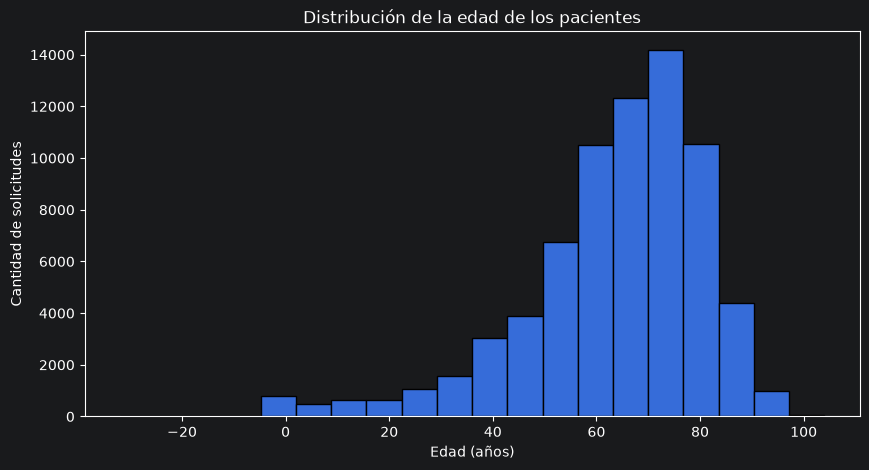

In [47]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["edad_años"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribución de la edad de los pacientes")
plt.xlabel("Edad (años)")
plt.ylabel("Cantidad de solicitudes")

plt.show()

##### Diagrama de caja de variables numerica

Se construye un diagrama de caja de la edad

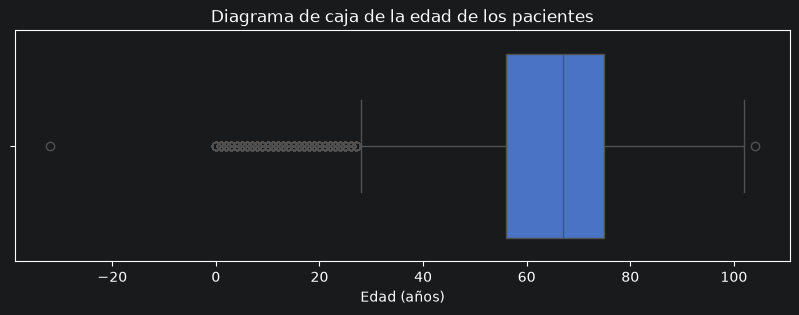

In [48]:
plt.figure(figsize=(10, 3))
sns.boxplot(
x=df["edad_años"])
plt.title("Diagrama de caja de la edad de los pacientes")
plt.xlabel("Edad (años)")
plt.show()

In [195]:
df["edad_años"].quantile([0.25, 0.50, 0.75])


0.25    56.0
0.50    67.0
0.75    75.0
Name: edad_años, dtype: float64

Agrupación de edad en rangos etarios

In [196]:
bins = [0, 18, 30, 45, 60, 75, 100]

labels = [
    "0-18",
    "19-30",
    "31-45",
    "46-60",
    "61-75",
    "76+"
]

df["grupo_edad"] = pd.cut(
    df["edad_años"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

Se analiza el estado de solicitud por intervalos de edad

In [197]:
tabla_pct = (
    pd.crosstab(
        df["grupo_edad"],
        df["estado_solicitud"],
        normalize="index"
    ) * 100
).round(2)

tabla_pct

estado_solicitud,AUTORIZADO,NO AUTORIZADO
grupo_edad,,
0-18,93.88,6.12
19-30,95.13,4.87
31-45,90.79,9.21
46-60,95.82,4.18
61-75,96.06,3.94
76+,96.37,3.63


Se diagrama el estado de solicitud por grupo etario

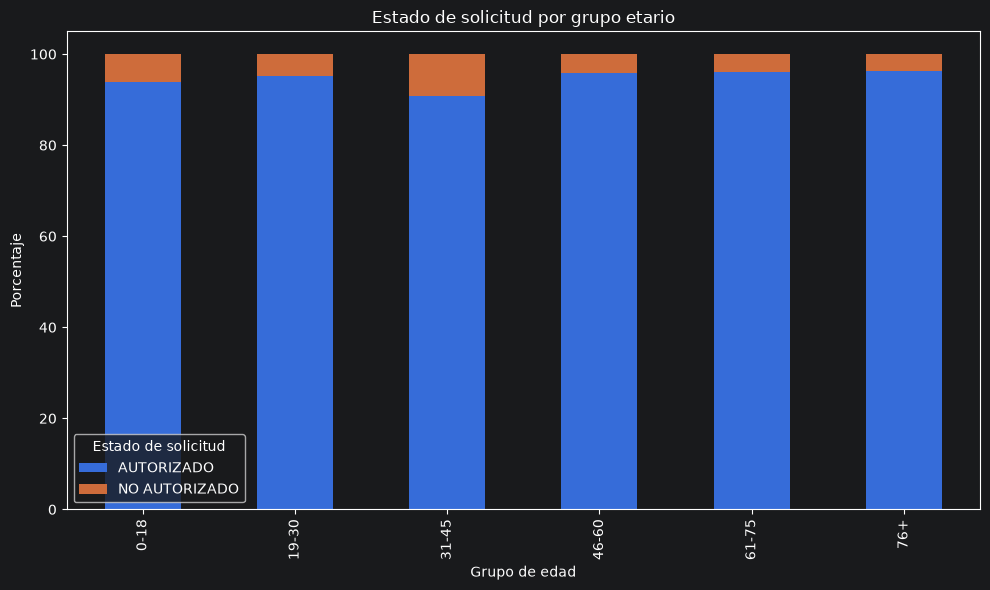

In [198]:
tabla_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Estado de solicitud por grupo etario")
plt.ylabel("Porcentaje")
plt.xlabel("Grupo de edad")
plt.legend(title="Estado de solicitud")
plt.tight_layout()
plt.show()

Conclusiones Edad:

- La edad media de los pacientes es de 63,5 años, mientras que la mediana es de 67 años.
- El 25 % de los registros corresponde a pacientes de hasta 56 años, mientras que el 75 % corresponde a pacientes de hasta 75 años.
- Por lo tanto, el 50 % central de los pacientes se encuentra entre los 56 y 75 años.
- El histograma muestra una mayor concentración de solicitudes en edades medias y avanzadas, especialmente entre los 55 y 80 años.
- La mediana es superior a la media, lo que es consistente con la presencia de pacientes jóvenes que desplazan la media hacia valores menores.
- La desviación estándar es de 17,54 años, mostrando una dispersión considerable de las edades.
- El rango de edad es amplio, desde recién nacidos hasta alcanzar los 104 años.
- Se observa un porcentaje de autorizaciones menor en el grupo etario entre 31-45 años

### Análisis Multivariante

#### Análisis numerico / numerico

Solo tenemos la variable edad como númerica, así que no podemos hacer este tipo de análisis.

#### Análisis categórico / categórico

Analizamos el target frente a las características categóricas, una a una.

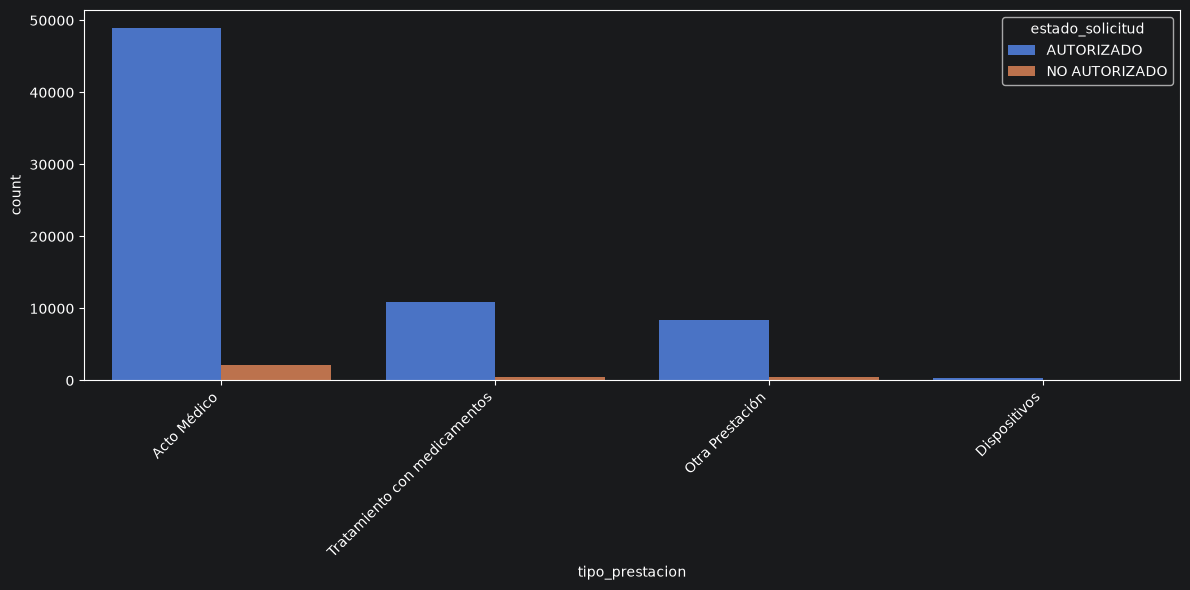

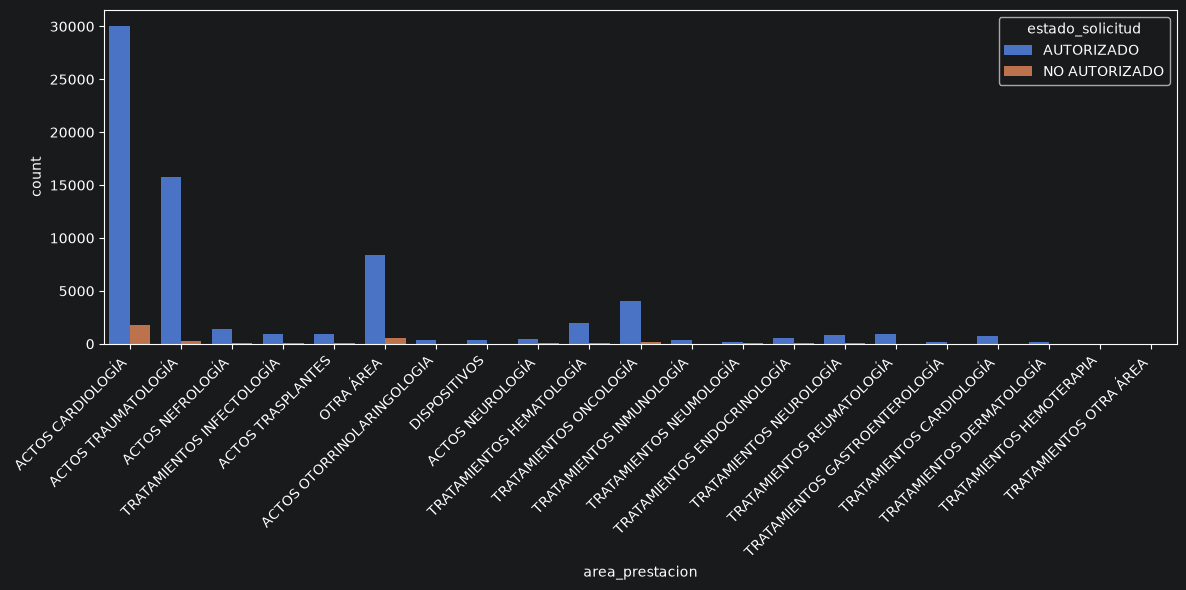

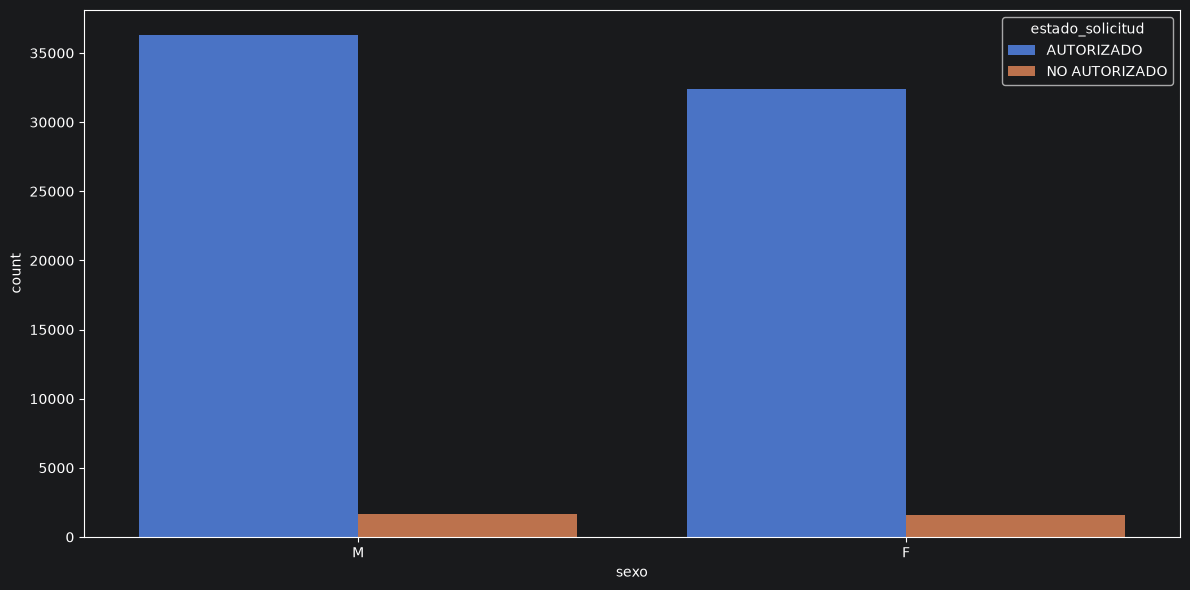

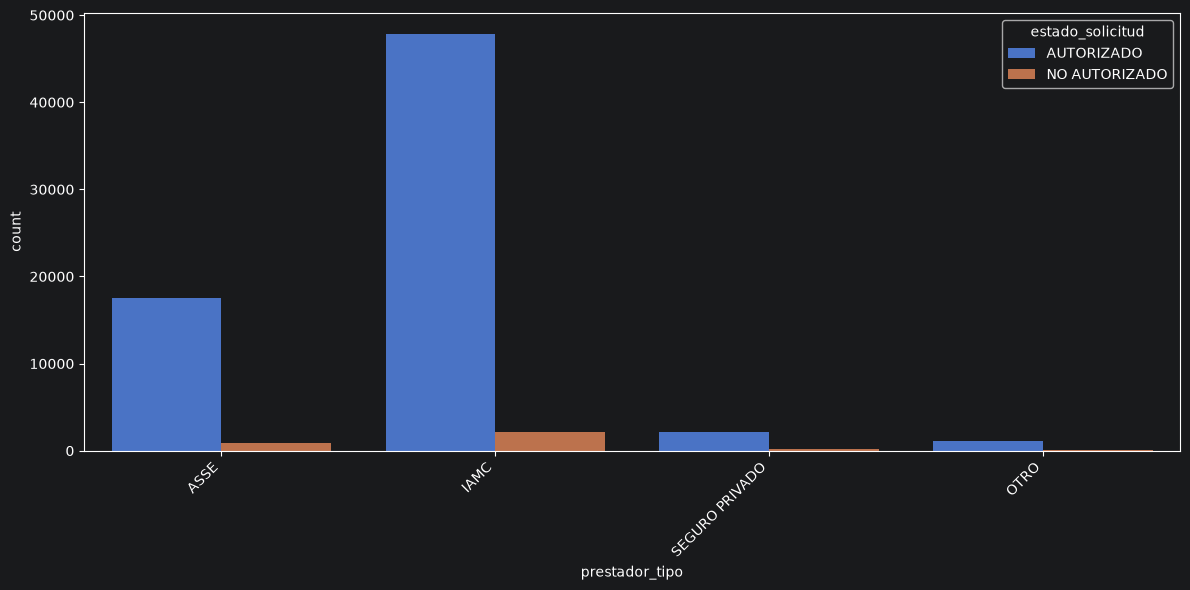

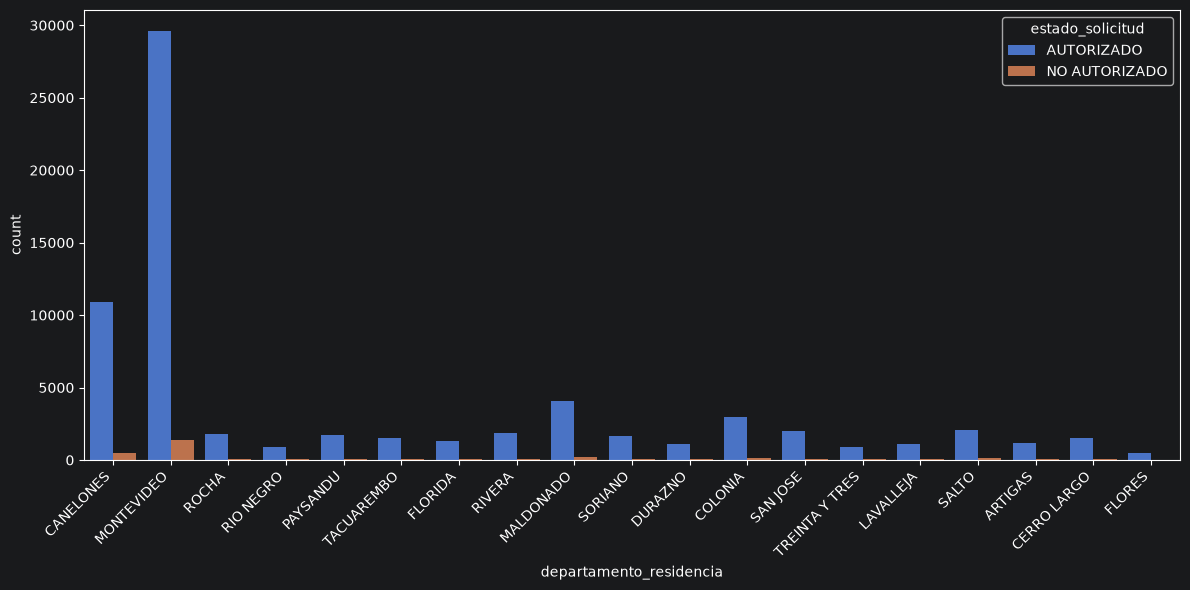

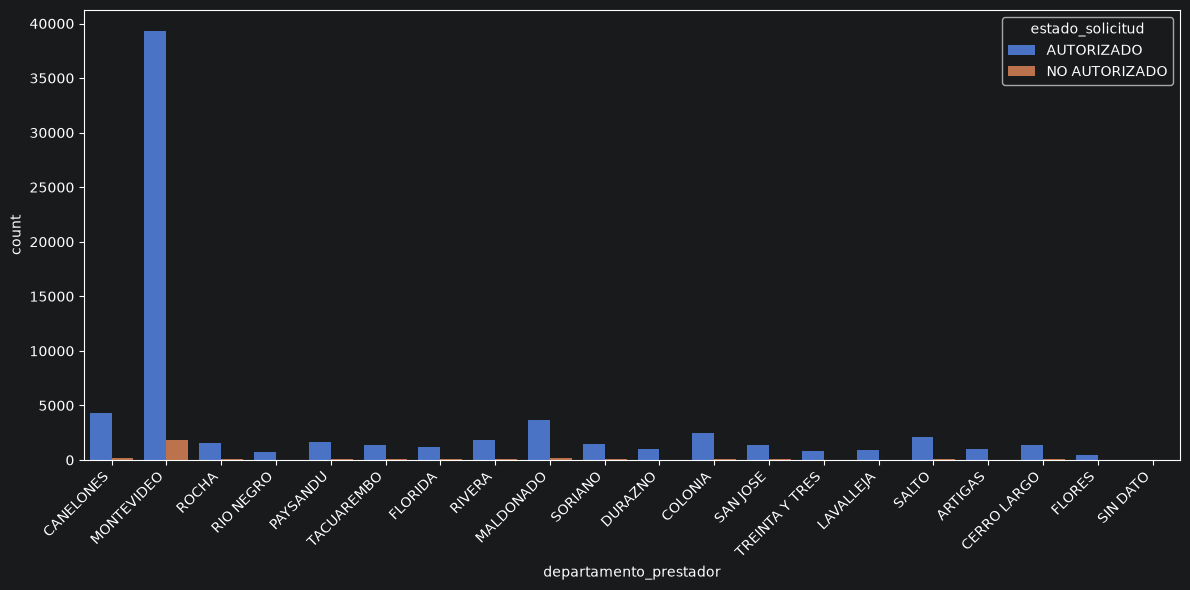

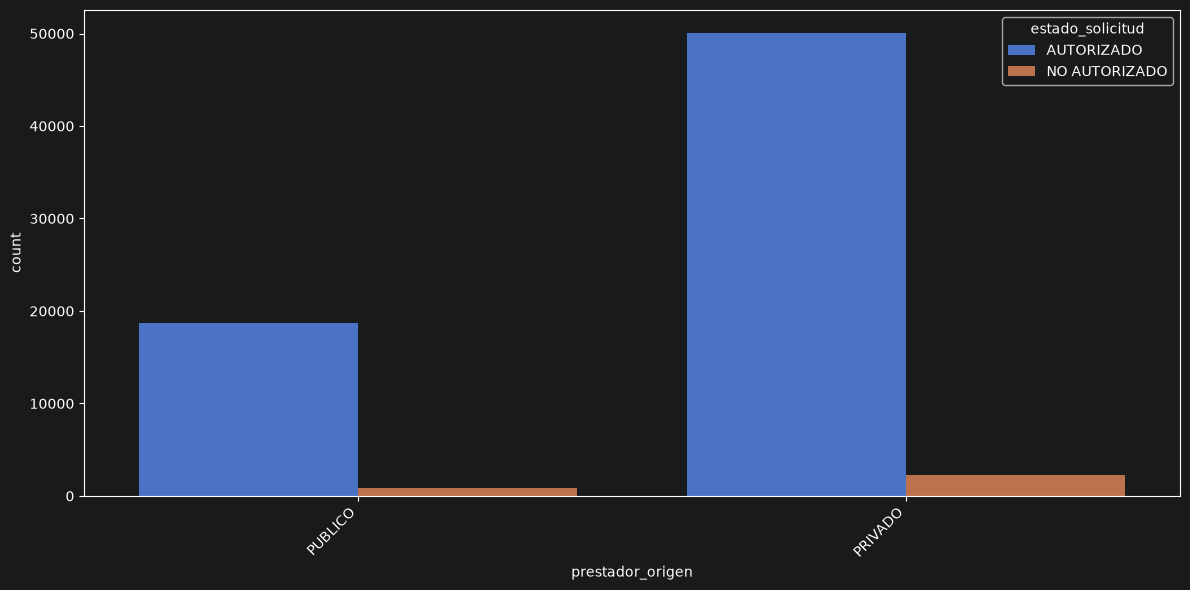

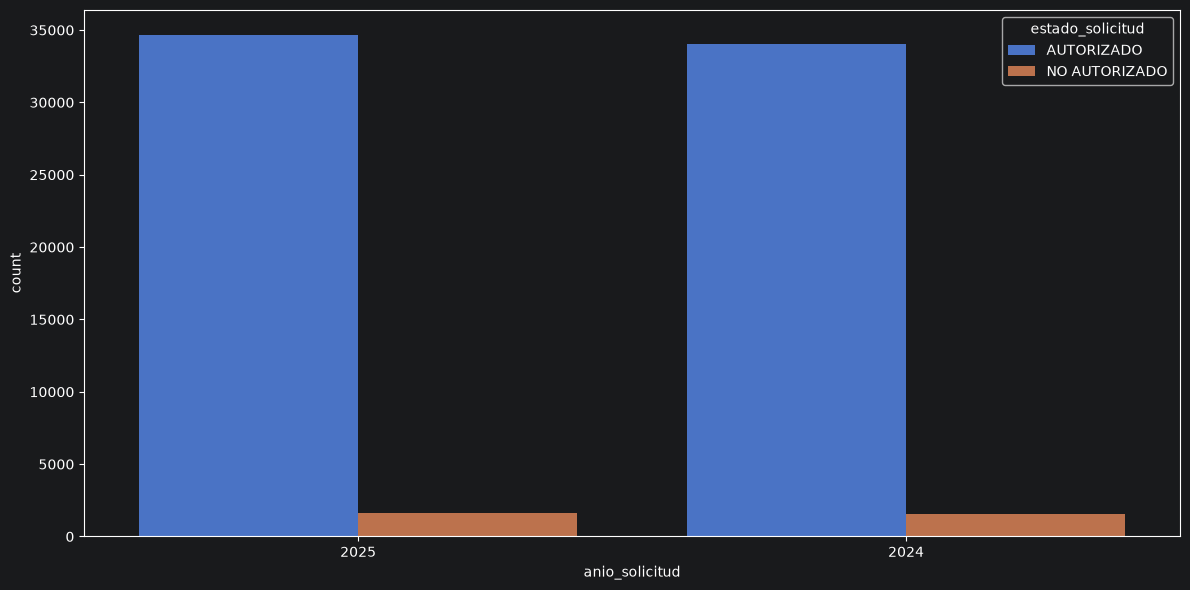

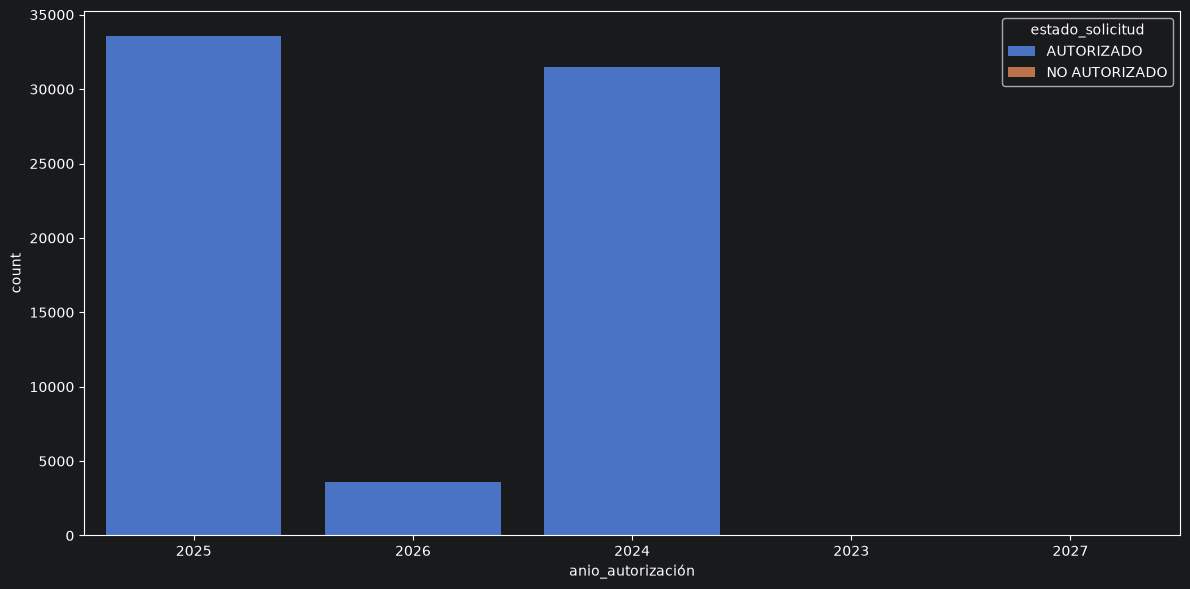

In [49]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="tipo_prestacion", hue="estado_solicitud")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(data=df, x="area_prestacion", hue="estado_solicitud")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(data=df, x="sexo", hue="estado_solicitud")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(data=df, x="prestador_tipo", hue="estado_solicitud")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(data=df, x="departamento_residencia", hue="estado_solicitud")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(data=df, x="departamento_prestador", hue="estado_solicitud")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(data=df, x="prestador_origen", hue="estado_solicitud")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(data=df, x="anio_solicitud", hue="estado_solicitud")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.countplot(data=df, x="anio_autorización", hue="estado_solicitud")
plt.tight_layout()
plt.show()

##### Observaciones
El estado de solicitud muestra un claro predominio de casos autorizados en todas las categorías analizadas.
A partir de la inspección visual no se observan diferencias sustanciales en el comportamiento del target según las variables analizadas. Las diferencias observadas parecen estar más asociadas al volumen de registros de cada categoría que a cambios en la proporción de autorizaciones.

#### Combinación de target frente a varias predictoras
Combinamos el target con varias predictoras al mismo tiempo para enriquecer el análisis.

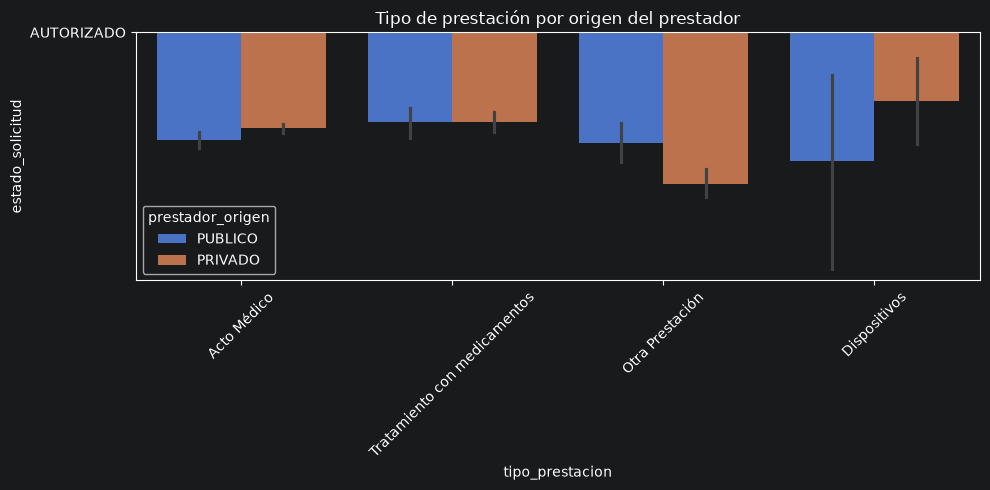

In [68]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="tipo_prestacion",
    y="estado_solicitud",
    hue="prestador_origen"
)

plt.title("Tipo de prestación por origen del prestador")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

No se avanza con este tipo de análisis porque la combinación de varias predictoras no muestra hallazgos significativos.

##### Análisis de Correlaciones #####

In [190]:
# Creo columnas numéricas para las variables categóricas
df["tipo_prestacion_n"] = pd.factorize(df["tipo_prestacion"])[0]
df["sexo_n"] = pd.factorize(df["sexo"])[0]
df["prestador_tipo_n"] = pd.factorize(df["prestador_tipo"])[0]
df["departamento_residencia_n"] = pd.factorize(df["departamento_residencia"])[0]
df["departamento_prestador_n"] = pd.factorize(df["departamento_prestador"])[0]
df["prestador_origen_n"] = pd.factorize(df["prestador_origen"])[0]
df["anio_solicitud_n"] = pd.factorize(df["anio_solicitud"])[0]
df["estado_solicitud_n"] = pd.factorize(df["estado_solicitud"])[0]

In [191]:
df[["tipo_prestacion_n","sexo_n","prestador_origen_n","departamento_residencia_n", "departamento_prestador_n", "prestador_origen_n", "anio_solicitud","estado_solicitud_n"]]

,tipo_prestacion_n,sexo_n,prestador_origen_n,departamento_residencia_n,departamento_prestador_n,prestador_origen_n,anio_solicitud,estado_solicitud_n
0,0,0,0,0,0,0,2025,0
1,0,0,0,1,1,0,2025,0
2,0,1,0,1,1,0,2025,0
3,0,0,0,2,2,0,2025,0
4,0,1,0,3,3,0,2025,0
...,...,...,...,...,...,...,...,...
71870,0,0,1,5,5,1,2024,0
71871,0,1,1,0,1,1,2024,0
71872,0,0,1,14,14,1,2024,0
71873,0,0,0,1,1,0,2024,0


In [192]:
df[['sexo', 'sexo_n']]

,sexo,sexo_n
0,M,0
1,M,0
2,F,1
3,M,0
4,F,1
...,...,...
71870,M,0
71871,F,1
71872,M,0
71873,M,0


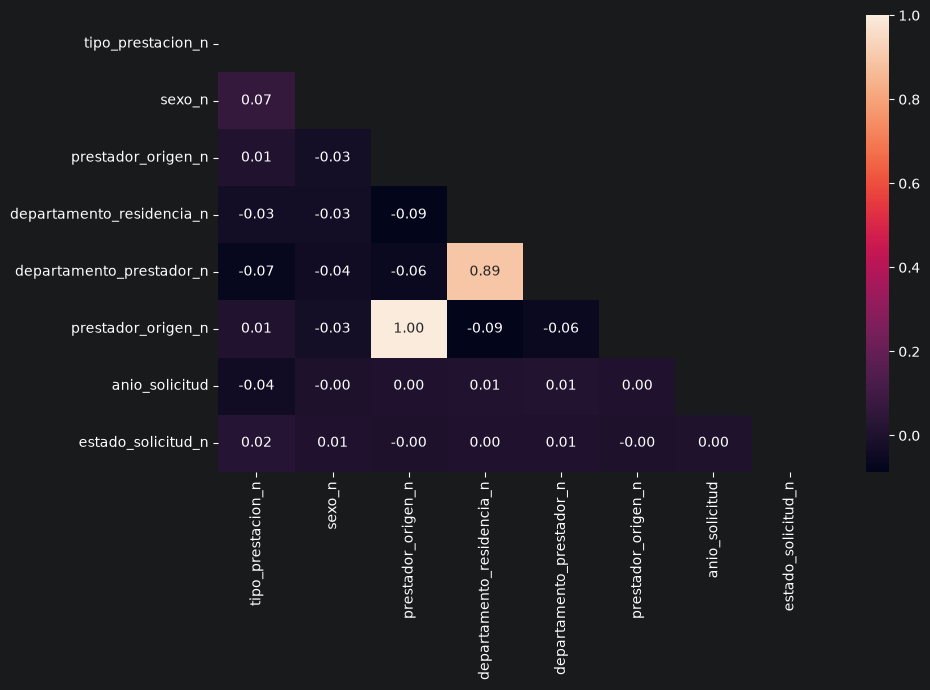

In [193]:
corr = df[["tipo_prestacion_n","sexo_n","prestador_origen_n","departamento_residencia_n", "departamento_prestador_n", "prestador_origen_n", "anio_solicitud","estado_solicitud_n"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

##### Conclusión matriz correlaciones:

La matriz de correlación muestra una escasa relación lineal entre las variables categóricas codificadas y el estado de solicitud, lo que sugiere que ninguna de ellas, analizada de forma aislada, tiene una asociación fuerte con la variable objetivo. La única relación destacable se observa entre el departamento de residencia y el departamento del prestador (0.89), indicando una estrecha correspondencia geográfica entre ambas variables. 